# Candlestick Chart Classification with CNN


> This notebook uses a basic CNN to classify Bitcoin candlestick charts as bearish, neutral, or bullish using images from the following [dataset](https://huggingface.co/datasets/tuankg1028/btc-candlestick-dataset).
>


In [46]:
!pip install datasets wandb torchinfo --quiet

In [47]:
!nvidia-smi

Thu Mar 12 21:07:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             35W /   70W |    1657MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Imports

In [48]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import torchvision
from torchvision.io import decode_image
from torchvision.utils import make_grid
from torchvision import transforms
import torchvision.transforms.v2 as T
import os
import gc
from tqdm import tqdm
from tqdm.auto import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import metrics as mt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import glob
import wandb
import matplotlib.pyplot as plt
import csv
import pandas as pd

from datasets import load_dataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", DEVICE)


Device:  cuda


# Download Data

In [49]:
hf_dataset = load_dataset("tuankg1028/btc-candlestick-dataset")

print("Train size:", len(hf_dataset["train"]))
print("Validation size:", len(hf_dataset["validation"]))
print("Test size:", len(hf_dataset["test"]))

Train size: 9417
Validation size: 1047
Test size: 2617


# Config

In [50]:
config = {
    'batch_size': 64, # Increase this if your GPU can handle it
    'lr': 0.01,
    'epochs': 60,
    'num_classes': 3, # 0 - bearish, 1 - neutral, 2 - bullish
    'checkpoint_dir': "./checkpoint", # Checkpoint directory
    'augument': True,
    'dropout': 0.3,
    'weight_decay': 1e-4,
    'label_names': ['bearish', 'neutral', 'bullish']
}

# Data Augumentations

In [51]:
def create_transforms(image_size: int = 112, augment: bool = True) -> T.Compose:
    """Create transform pipeline for face recognition."""

    # Step 1: Basic transformations
    transform_list = [
        # Resize the image to the desired size (image_size x image_size)
        T.Resize((image_size, image_size)),

        # Convert PIL Image to tensor
        T.ToTensor(),

        # Convert image to float32 and scale the pixel values to [0, 1]
        T.ToDtype(torch.float32, scale=True),
    ]

    # Step 2: Data augmentation (optional, based on `augment` argument)
    if augment:  # This block will be executed if `augment=True`
        transform_list.extend([
            T.RandomRotation(degrees=5),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            T.RandomErasing(p=0.2, scale=(0.02, 0.1))
        ])

    # Step 3: Standard normalization for image recognition tasks
    # The Normalize transformation requires mean and std values for each channel (R, G, B).
    # Here, we are normalizing the pixel values to have a mean of 0.5 and std of 0.5 for each channel.
    transform_list.extend([
        T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Standard mean and std for face recognition tasks
    ])

    # Return the composed transformation pipeline
    return T.Compose(transform_list)


In [52]:
train_transforms = create_transforms(augment=config['augument'])
val_transforms   = create_transforms(augment=False)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


# Datasets and DataLoaders

## Classification Datasets and Dataloaders

In [53]:
class CandlestickDataset(Dataset):
    """Custom dataset for the HuggingFace candlestick dataset for Python."""

    def __init__(self, hf_split, transform=None):
        """
        Args:
            hf_split: HuggingFace dataset split
            transform (callable): Transform applied to images.
        """
        self.data = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = item["image"].convert("RGB")

        label = int(item["label"])

        if self.transform:
          image = self.transform(image)

        return image, label


In [54]:
# Datasets
train_dataset = CandlestickDataset(hf_dataset["train"], train_transforms)
val_dataset   = CandlestickDataset(hf_dataset["validation"], val_transforms)
test_dataset  = CandlestickDataset(hf_dataset["test"], val_transforms)

# Dataloaders
train_loader = torch.utils.data.DataLoader(
    dataset     = train_dataset,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader   = torch.utils.data.DataLoader(
    dataset     = val_dataset,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    persistent_workers=True,
    prefetch_factor=2
)
test_loader  = torch.utils.data.DataLoader(
    dataset     = test_dataset,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    persistent_workers=True,
    prefetch_factor=2
)

To handle the imbalance issue, we compute the class weights and train the model using weighted loss

In [55]:
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# collect labels from training set
labels = [train_dataset[i][1] for i in range(len(train_dataset))]


class_counts = Counter(labels)
print("Class counts:", class_counts)

num_classes = len(class_counts)
total = sum(class_counts.values())

class_weights = torch.tensor(
    [total / class_counts[i] for i in range(num_classes)],
    dtype=torch.float32
)

class_weights = class_weights / class_weights.sum() * num_classes
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class counts: Counter({1: 7380, 2: 1064, 0: 973})
Class weights: tensor([1.4660, 0.1933, 1.3407], device='cuda:0')


# EDA and Viz

In [56]:
# Double-check your dataset/dataloaders work as expected

print("No. of train images  : ", train_dataset.__len__())
print("Shape of image       : ", train_dataset[0][0].shape)
print("Batch size           : ", config['batch_size'])
print("Train batches        : ", train_loader.__len__())
print("Val batches          : ", val_loader.__len__())

# Feel free to print more things if needed

No. of train images  :  9417
Shape of image       :  torch.Size([3, 112, 112])
Batch size           :  64
Train batches        :  148
Val batches          :  17


### Classification Dataset Viz

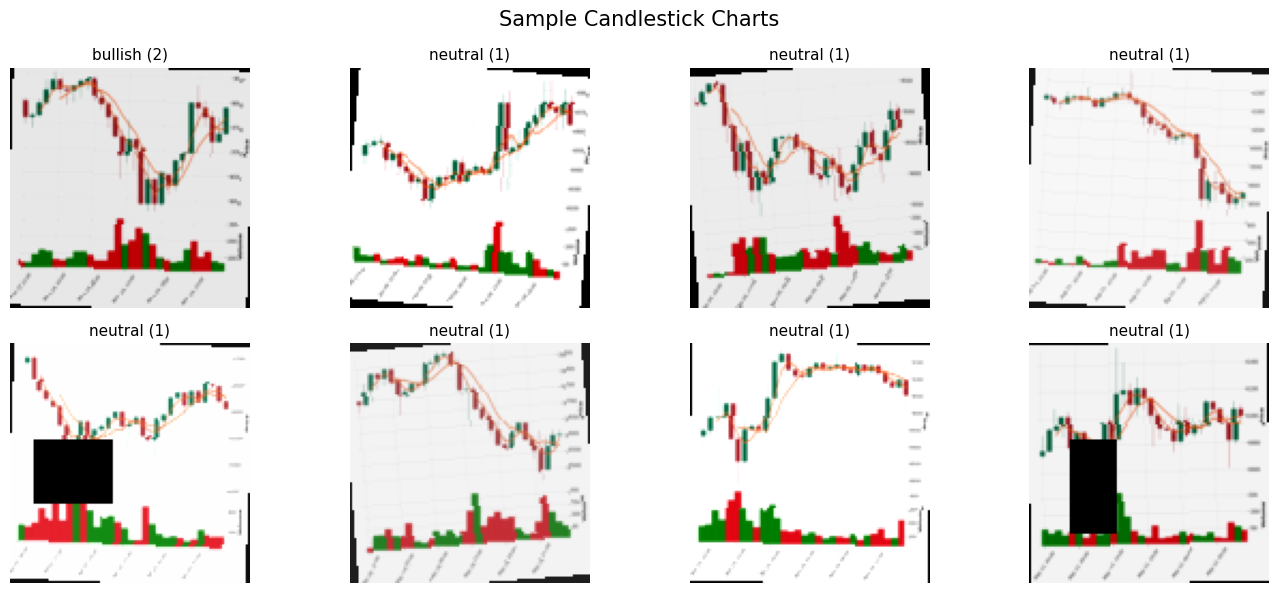

In [57]:
def show_samples(data, n=8):
    """
    Display candlestick images with their labels
    """
    _, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    label_names = config["label_names"]

    for i, ax in enumerate(axes.flat):
      img, label = data[i]

      img = img * 0.5 + 0.5 # reverse normalization
      img = img.permute(1, 2, 0).numpy().clip(0, 1)
      ax.imshow(img)
      ax.set_title(f"{label_names[label]} ({label})", fontsize=11)
      ax.axis("off")

    plt.suptitle("Sample Candlestick Charts", fontsize=15)
    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

# Model Architecture

In [58]:
class Bottleneck(nn.Module):
  """
  Bottleneck used for ResNet 50
  """
  expansion = 4

  def __init__(self, in_channels, out_channels, stride=1, downsample=None):
    super().__init__()

    # 1 x 1 conv to reduce
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
    self.batchnorm1 = nn.BatchNorm2d(out_channels)

    # 3 x 3 conv to process
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.batchnorm2 = nn.BatchNorm2d(out_channels)

    # 1 x 1 conv to expand
    self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
    self.batchnorm3 = nn.BatchNorm2d(out_channels * self.expansion)

    self.relu = nn.ReLU(inplace=True)
    self.downsample = downsample

  def forward(self, x):
    id = x

    # reduce
    output = self.conv1(x)
    output = self.batchnorm1(output)
    output = self.relu(output)

    # process
    output = self.conv2(output)
    output = self.batchnorm2(output)
    output = self.relu(output)

    # expand
    output = self.conv3(output)
    output = self.batchnorm3(output)

    if self.downsample is not None:
      id = self.downsample(x)

    output += id
    output = self.relu(output)

    return output

class ResNet(nn.Module):
    """
    ResNet Architecture
    """

    def __init__(self, block, layers, num_classes, embedding_dim=128, dropout=0.3):
      """
      block - block type
      layers - number of blocks per layer
      num_class - number of output classes
      embedding_dim - dim of the embedding
      dropout - rate of dropout
      """
      super().__init__()

      self.in_channels = 64

      self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
      self.batchnorm1 = nn.BatchNorm2d(64)
      self.relu = nn.ReLU(inplace=True)

      self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

      self.layer1 = self.make_layer(block, 64, layers[0], stride=1)
      self.layer2 = self.make_layer(block, 128, layers[1], stride=2)
      self.layer3 = self.make_layer(block, 256, layers[2], stride=2)
      self.layer4 = self.make_layer(block, 512, layers[3], stride=2)

      self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

      feature_dim = 512 * block.expansion

      self.embedding = nn.Sequential(
         nn.Linear(feature_dim, embedding_dim),
         nn.BatchNorm1d(embedding_dim)
      )

      self.dropout = nn.Dropout(p=dropout)

      self.cls_layer = nn.Linear(embedding_dim, num_classes)

    def make_layer(self, block, out_channels, num_blocks, stride):
      downsample = None

      if stride != 1 or self.in_channels != out_channels * block.expansion:
        downsample = nn.Sequential(
            nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels * block.expansion)
        )

      layers = []

      layers.append(block(self.in_channels, out_channels, stride, downsample))
      self.in_channels = out_channels * block.expansion

      for _ in range(1, num_blocks):
        layers.append(block(self.in_channels, out_channels))

      return nn.Sequential(*layers)

    def forward(self, x):
      x = self.conv1(x)
      x = self.batchnorm1(x)
      x = self.relu(x)
      x = self.maxpool(x)

      x = self.layer1(x)
      x = self.layer2(x)
      x = self.layer3(x)
      x = self.layer4(x)

      x = self.avgpool(x)
      x = torch.flatten(x, 1)

      feats = self.embedding(x)
      feats = self.dropout(feats)

      out = self.cls_layer(feats)

      return {"feats": feats, "out": out}

class Network(nn.Module):
    """
    Simple 5-layer CNN backbone for face classification and feature extraction.
    """

    def __init__(self, num_classes: int):
        super().__init__()
        self.backbone = torch.nn.Sequential(
            torch.nn.Conv2d(3, 64, 7, stride=4, padding=3),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),

            torch.nn.Conv2d(64, 128, 3, stride=2, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),

            torch.nn.Conv2d(128, 256, 3, stride=2, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),

            torch.nn.Conv2d(256, 512, 3, stride=2, padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),

            torch.nn.Conv2d(512, 1024, 3, stride=2, padding=1),
            torch.nn.BatchNorm2d(1024),
            torch.nn.ReLU(),

            torch.nn.Conv2d(1024, 512, 3, stride=1, padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),

            torch.nn.Conv2d(512, 512, 3, stride=1, padding=1),
            torch.nn.BatchNorm2d(512),
            torch.nn.ReLU(),

            torch.nn.Conv2d(512, 1024, 3, stride=1, padding=1),
            torch.nn.BatchNorm2d(1024),
            torch.nn.ReLU(),

        )
        self.dropout = torch.nn.Dropout(p=dropout)
        self.pool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.cls_layer = torch.nn.Linear(512, num_classes)

    def forward(self, x, return_feats: bool = False):
        """
        Args:
            x (Tensor): Input image batch of shape (B, 3, H, W)
            return_feats (bool): If True, return only feature embeddings

        Returns:
            dict with keys:
                - 'feats': feature embeddings
                - 'out': classification logits
        """
        feats = self.pool(self.backbone(x)).flatten(1)
        feats = self.dropout(feats)
        out = self.cls_layer(feats)
        return {"feats": feats, "out": out}


# Initialize model
# model = Network(num_classes=config["num_classes"]).to(DEVICE)
model = ResNet(Bottleneck, [3, 4, 6, 3], config["num_classes"], embedding_dim=128, dropout=config["dropout"]).to(DEVICE)

# Optional: model summary
summary(model, (3, 112, 112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]           9,408
       BatchNorm2d-2           [-1, 64, 56, 56]             128
              ReLU-3           [-1, 64, 56, 56]               0
         MaxPool2d-4           [-1, 64, 28, 28]               0
            Conv2d-5           [-1, 64, 28, 28]           4,096
       BatchNorm2d-6           [-1, 64, 28, 28]             128
              ReLU-7           [-1, 64, 28, 28]               0
            Conv2d-8           [-1, 64, 28, 28]          36,864
       BatchNorm2d-9           [-1, 64, 28, 28]             128
             ReLU-10           [-1, 64, 28, 28]               0
           Conv2d-11          [-1, 256, 28, 28]          16,384
      BatchNorm2d-12          [-1, 256, 28, 28]             512
           Conv2d-13          [-1, 256, 28, 28]          16,384
      BatchNorm2d-14          [-1, 256,

# Loss | Optimizer | Scheduler

In [59]:
# ---------------------------------------------------
# Loss Function
# ---------------------------------------------------

# criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

# ---------------------------------------------------
# Optimizer
# ---------------------------------------------------

optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config["weight_decay"])

# ---------------------------------------------------
# Learning Rate Scheduler
# ---------------------------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=1e-6)

# ---------------------------------------------------
# Mixed-Precision Training (FP16)
# ---------------------------------------------------

# GradScaler enables stable mixed-precision training on supported GPUs (e.g., T4, V100).
# This reduces memory usage and can significantly speed up training.
scaler = torch.amp.GradScaler(device='cuda')

# Metrics

In [60]:
class AverageMeter:
    """
    Tracks and computes the running average of a scalar metric.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0.0
        self.avg = 0.0
        self.sum = 0.0
        self.count = 0

    def update(self, val, n: int = 1):
        self.val = float(val)
        self.sum += val * n
        self.count += n
        self.avg = self.sum / max(self.count, 1)


def topk_accuracy(logits: torch.Tensor, targets: torch.Tensor, topk=(1,)):
    """
    Computes top-k accuracy for the given logits and targets.

    Args:
        logits (Tensor): Model outputs of shape (B, C)
        targets (Tensor): Ground-truth labels of shape (B,)
        topk (tuple): Values of k for top-k accuracy

    Returns:
        List[Tensor]: Accuracy values in percentage for each k
    """
    maxk = min(max(topk), logits.size(1))
    batch_size = targets.size(0)

    _, preds = logits.topk(maxk, dim=1, largest=True, sorted=True)
    preds = preds.t()
    correct = preds.eq(targets.view(1, -1))

    accuracies = []
    for k in topk:
        k = min(k, maxk)
        correct_k = correct[:k].reshape(-1).float().sum(0)
        accuracies.append(correct_k * 100.0 / batch_size)

    return accuracies


# Train and Validation Function

In [68]:
def train_epoch(
    model,
    dataloader,
    optimizer,
    scheduler,
    scaler,
    device,
    criterion,
):
    """
    Runs one training epoch.

    Args:
        model (nn.Module): Model to train
        dataloader (DataLoader): Training dataloader
        optimizer (Optimizer): Optimizer
        scheduler (LRScheduler or None): Learning rate scheduler
        scaler (GradScaler): AMP gradient scaler
        device (torch.device): Training device
        criterion (callable): Loss function

    Returns:
        tuple: (avg_accuracy, avg_loss)
    """
    model.train()

    loss_meter = AverageMeter()
    acc_meter = AverageMeter()

    progress = tqdm(
        dataloader,
        desc="Train",
        dynamic_ncols=True,
        leave=False,
    )

    for images, labels in progress:
        optimizer.zero_grad(set_to_none=True)

        # Move data to device
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass (mixed precision)
        with torch.amp.autocast(device_type = 'cuda'):
            outputs = model(images)
            logits = outputs["out"]
            loss = criterion(logits, labels)

        # Backward + optimizer step (AMP-safe)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        batch_loss = loss.item()
        loss_meter.update(batch_loss)

        with torch.no_grad():
            batch_acc = topk_accuracy(logits, labels, topk=(1,))[0].item()
            acc_meter.update(batch_acc)

        # Progress bar update
        progress.set_postfix(
            loss=f"{batch_loss:.4f} ({loss_meter.avg:.4f})",
            acc=f"{batch_acc:.2f}% ({acc_meter.avg:.2f}%)",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )

    # Step scheduler once per epoch (for epoch-based schedulers)
    if scheduler is not None:
        scheduler.step()

    return acc_meter.avg, loss_meter.avg

In [69]:
@torch.no_grad()
def valid_epoch(
    model,
    dataloader,
    device,
    criterion,
):
    """
    Runs one validation epoch for classification.

    Args:
        model (nn.Module): Trained model
        dataloader (DataLoader): Validation dataloader
        device (torch.device): Evaluation device
        criterion (callable): Loss function

    Returns:
        tuple: (avg_accuracy, avg_loss)
    """
    model.eval()

    loss_meter = AverageMeter()
    acc_meter = AverageMeter()

    progress = tqdm(
        dataloader,
        desc="Val",
        dynamic_ncols=True,
        leave=False,
    )

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Forward pass (inference-only)
        outputs = model(images)
        logits = outputs["out"]
        loss = criterion(logits, labels)

        # Metrics
        batch_loss = loss.item()
        loss_meter.update(batch_loss)

        batch_acc = topk_accuracy(logits, labels, topk=(1,))[0].item()
        acc_meter.update(batch_acc)

        # Progress bar update
        progress.set_postfix(
            loss=f"{batch_loss:.4f} ({loss_meter.avg:.4f})",
            acc=f"{batch_acc:.2f}% ({acc_meter.avg:.2f}%)",
        )

    return acc_meter.avg, loss_meter.avg


In [63]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

# WandB

In [64]:
wandb.login()

True

In [65]:
# Create your wandb run
run = wandb.init(
    name = f"Gradient Clipping", ### Change this to your desired run name
    project = "11-785 - Group 13", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

# Checkpointing and Loading Model

In [66]:
# Ensure checkpoint directory exists
checkpoint_dir = config.get("checkpoint_dir", "./checkpoints")
os.makedirs(checkpoint_dir, exist_ok=True)


def save_model(model, optimizer, scheduler, metrics, epoch, path):
    """
    Saves model, optimizer, scheduler, and training metrics to a checkpoint.

    Args:
        model (nn.Module): Model to save
        optimizer (Optimizer): Optimizer
        scheduler (LRScheduler): Learning rate scheduler
        metrics (dict): Dictionary of tracked metrics
        epoch (int): Current epoch
        path (str): Path to save checkpoint
    """
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
            "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
            "metrics": metrics,
            "epoch": epoch,
        },
        path,
    )
    print(f"Checkpoint saved at {path}")


def load_model(model, path, device=None):
    """
    Loads model, optimizer, scheduler, and metrics from a checkpoint.

    Args:
        model (nn.Module): Model to load weights into
        optimizer (Optimizer, optional): Optimizer to load state
        scheduler (LRScheduler, optional): Scheduler to load state
        path (str): Path to checkpoint file
        device (torch.device, optional): Device mapping for checkpoint

    Returns:
        tuple: model, optimizer, scheduler, epoch, metrics
    """
    checkpoint = torch.load(path, map_location=device)
    state = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state, strict=True)
    model.to(device)
    return model


# Experiments

In [70]:
# Training setup
start_epoch = 0
best_val_acc = 0.0

history = {"train_acc": [], "train_loss": [], "val_acc": [], "val_loss": []}

for epoch in range(start_epoch, config["epochs"]):
    print(f"\n=== Epoch {epoch + 1}/{config['epochs']} ===")

    # -----------------------------
    # Train
    # -----------------------------
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, criterion
    )
    curr_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Train | Acc: {train_acc:.4f}% | Loss: {train_loss:.4f} | LR: {curr_lr:.6f}"
    )

    metrics = {
        "train_acc": train_acc,
        "train_loss": train_loss,
        "lr": curr_lr,
    }

    # -----------------------------
    # Classification Validation
    # -----------------------------
    if eval:
        valid_acc, valid_loss = valid_epoch(model, val_loader, DEVICE, criterion)
        print(f"Val  | Acc: {valid_acc:.4f}% | Loss: {valid_loss:.4f}")
        metrics.update({
            "valid_acc": valid_acc,
            "valid_loss": valid_loss,
        })

    history["train_acc"].append(train_acc)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(valid_acc)
    history["val_loss"].append(valid_loss)


    # -----------------------------
    # Save checkpoints
    # -----------------------------
    checkpoint_path = os.path.join(config["checkpoint_dir"], "last.pth")
    save_model(model, optimizer, scheduler, metrics, epoch, checkpoint_path)
    print(f"Saved last epoch model: {checkpoint_path}")

    if valid_acc > best_val_acc:
        best_val_acc = valid_acc
        best_path = os.path.join(config["checkpoint_dir"], "best.pth")
        save_model(model, optimizer, scheduler, metrics, epoch, best_path)

        if "wandb" in globals():
            wandb.save(best_path)

        print(f"Saved best retrieval model (by EER): {best_path}")

    # -----------------------------
    # Log metrics
    # -----------------------------
    if "run" in globals() and run is not None:
        run.log(metrics)


=== Epoch 1/60 ===


Train:   0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_26816/4291406645.py:53: FutureWarning: `torch.nn.utils.clip_grad_norm` is now deprecated in favor of `torch.nn.utils.clip_grad_norm_`.
  torch.nn.utils.clip_grad_norm(model.parameters(), 1.0)


Train | Acc: 22.3231% | Loss: 1.2744 | LR: 0.009993


Val:   0%|          | 0/17 [00:00<?, ?it/s]

...

Val  | Acc: 89.1624% | Loss: 0.6694
Checkpoint saved at ./checkpoint/last.pth
Saved last epoch model: ./checkpoint/last.pth

=== Epoch 60/60 ===


Train:   0%|          | 0/148 [00:00<?, ?it/s]

Train | Acc: 97.7618% | Loss: 0.3690 | LR: 0.000001


Val:   0%|          | 0/17 [00:00<?, ?it/s]

Val  | Acc: 88.9786% | Loss: 0.6803
Checkpoint saved at ./checkpoint/last.pth
Saved last epoch model: ./checkpoint/last.pth


In [71]:
# -----------------------------
# Finish wandb run
# -----------------------------
if "run" in globals() and run is not None:
    run.finish()

lr,████████▇▇▇▇▇▆▆▅▅▅▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_acc,▁▁▁▃▄▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████████
train_loss,███▆▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▂▄▆▇▇▇▇▇▇▇▇▇▇▆▇█▇▇█████▇██████████████
valid_loss,█▅▂▂▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▁▂▂▃▂▂▂▂▃▂▃▃▃
lr,0.0
train_acc,97.76182
train_loss,0.36898
valid_acc,88.97858
valid_loss,0.68034


# Inference

In [72]:
model = load_model(model, os.path.join(config["checkpoint_dir"], "best.pth"), DEVICE)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in tqdm(test_loader, desc="Test"):
    images = images.to(DEVICE, non_blocking=True)
    logits = model(images)["out"]
    preds = logits.argmax(dim=1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean() * 100
print(f"\nTest Accuracy: {test_acc:.2f}%")

Test:   0%|          | 0/41 [00:00<?, ?it/s]


Test Accuracy: 89.80%


In [73]:
print(classification_report(
    all_labels, all_preds,
    target_names=config["label_names"],
    digits=3
))

              precision    recall  f1-score   support

     bearish      0.745     0.842     0.790       284
     neutral      0.941     0.927     0.934      2041
     bullish      0.766     0.750     0.758       292

    accuracy                          0.898      2617
   macro avg      0.817     0.840     0.827      2617
weighted avg      0.900     0.898     0.899      2617



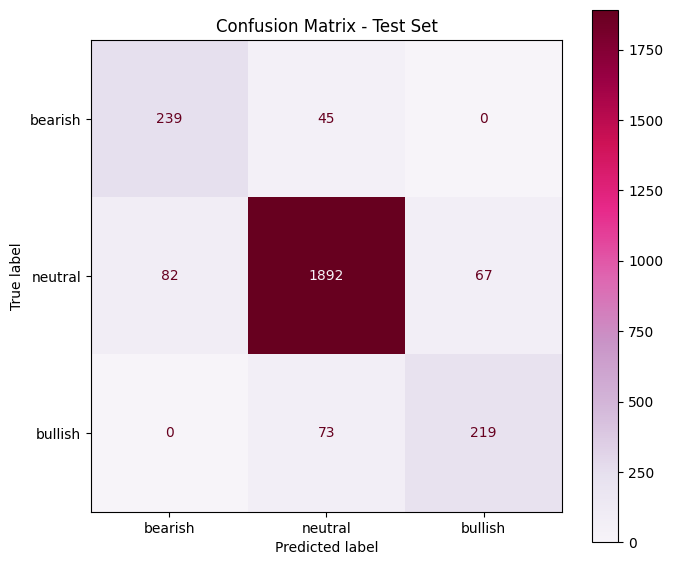

In [74]:
disp = ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds), display_labels=config["label_names"])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="PuRd", values_format="d")
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()